In [1]:
#importing the libraries
import pandas as pd
import numpy as np
#opening Csv file
df = pd.read_csv('Product_Recommendation.csv')


In [3]:
df.head()

,Customer_ID,Age,Gender,Location,Income,Browsing_History,Previous_Purchases,Preferred_Device,Product_Category,Time_Spent_on_Site
0,af09abc0-4835-4376-af52-758c10ff7e97,72,Male,Suburban,NaN,Clothing,8,Desktop,Clothing,78.718422
1,00ce02c1-d45a-4e5a-bd6e-d34d11f90647,72,Female,Rural,100071.0,Books,1,Desktop,Clothing,71.882840
2,b59bc34e-84de-4cc2-b45a-8e5254b5b7bf,72,Male,Urban,25734.0,Sports,1,Mobile,Food,105.186397
3,820cb025-c3e9-4a92-9ca6-91fb303b526e,22,Male,Rural,115576.0,Food,7,Desktop,Food,98.117595
4,232f52b9-3f95-4c70-91e3-ec9585c91802,33,Female,Rural,130314.0,Clothing,2,Mobile,Clothing,119.650952


In [5]:
# Deleting customer ID,Preferred_Device column as it has no influence on target variable
df =df.drop(['Customer_ID','Preferred_Device'],axis=1)


In [7]:
# Checking for count of null values inn the dataset in every column
df.isnull().sum()


Age                     0
Gender                143
Location                0
Income                118
Browsing_History        0
Previous_Purchases      0
Product_Category        0
Time_Spent_on_Site     27
dtype: int64

In [9]:
#Filling Null Values
x = df.select_dtypes(include=['object']).columns
df[x] = df[x].fillna(df[x].mode().iloc[0])
y = df.select_dtypes(include= ['float64']).columns
df[y] = df[y].fillna(df[y].mean())
p = df.select_dtypes(include= ['int64']).columns
df[p] = df[p].fillna(df[p].mean())


In [11]:
#Encoding Values using OneHotEncoder

from sklearn.preprocessing import OneHotEncoder
z = OneHotEncoder(sparse_output=False)
encoded_dataframes = []
for column in x:
    encoded = z.fit_transform(df[[column]])
    encoded_df = pd.DataFrame(encoded, columns=z.get_feature_names_out([column]))
    encoded_dataframes.append(encoded_df)

df = pd.concat([df.drop(columns=x)] + encoded_dataframes, axis=1)


In [13]:
# Scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[y] = scaler.fit_transform(df[y])
df[p] = scaler.fit_transform(df[p])
print(df)


          Age    Income  Previous_Purchases  Time_Spent_on_Site  \
0    0.885246  0.496413               0.875            0.641796   
1    0.885246  0.617502               0.000            0.582212   
2    0.885246  0.042828               0.000            0.872513   
3    0.065574  0.737366               0.750            0.810896   
4    0.245902  0.851301               0.125            0.998598   
..        ...       ...                 ...                 ...   
795  0.344262  0.926543               1.000            0.759107   
796  0.081967  0.572896               0.000            0.406973   
797  0.442623  0.852105               1.000            0.301804   
798  0.983607  0.519454               0.875            0.383333   
799  0.721311  0.463407               0.500            0.500028   

     Gender_Female  Gender_Male  Gender_Other  Location_Rural  \
0              0.0          1.0           0.0             0.0   
1              1.0          0.0           0.0             1.0   


In [19]:
#Splitting the dataset for Training and testing
target_columns = [col for col in df.columns if col.startswith('Product_Category_')]
b = df[target_columns]
a = df.drop(target_columns, axis=1)



In [21]:
#Testing and Training the dataset
from sklearn.model_selection import train_test_split
a_train, a_test, b_train, b_test = train_test_split(a, b, test_size=0.2, random_state=42)
print(f"Feature training set shape: {a_train.shape}")
print(f"Feature testing set shape: {a_test.shape}")
print(f"Target training set shape: {b_train.shape}")
print(f"Target testing set shape: {b_test.shape}")


Feature training set shape: (640, 15)
Feature testing set shape: (160, 15)
Target training set shape: (640, 5)
Target testing set shape: (160, 5)


In [23]:
# Importing Linear regression Algorithm 

from sklearn.linear_model import LinearRegression
linreg_model = LinearRegression()
linreg_model.fit(a_train, b_train)


LinearRegression()

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#Calculating metrics
linreg_pred = linreg_model.predict(a_test)
linreg_mse = mean_squared_error(b_test, linreg_pred)
linreg_mae = mean_absolute_error(b_test, linreg_pred)
linreg_r2 = r2_score(b_test, linreg_pred)
print(f'Mean Squared Error: {linreg_mse}')
print(f'Mean Absolute Error: {linreg_mae}')
print(f'R-squared: {linreg_r2}')


Mean Squared Error: 0.16727315425724013
Mean Absolute Error: 0.3237817511522894
R-squared: -0.047182949628638005


In [27]:
#Importing RandomForest Regressor

from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor()
rf_model.fit(a_train, b_train) 
# Evaluate Random Forest Classifier model
rf_pred = rf_model.predict(a_test)
rf_mse = mean_squared_error(b_test, rf_pred)
rf_mae = mean_absolute_error(b_test, rf_pred)
rf_r2 = r2_score(b_test, rf_pred)
print(f'Mean Squared Error: {rf_mse}')
print(f'Mean Absolute Error: {rf_mae}')
print(f'R-squared: {rf_r2}')


Mean Squared Error: 0.17455600000000007
Mean Absolute Error: 0.32330000000000003
R-squared: -0.09754948458684246


Matplotlib is building the font cache; this may take a moment.


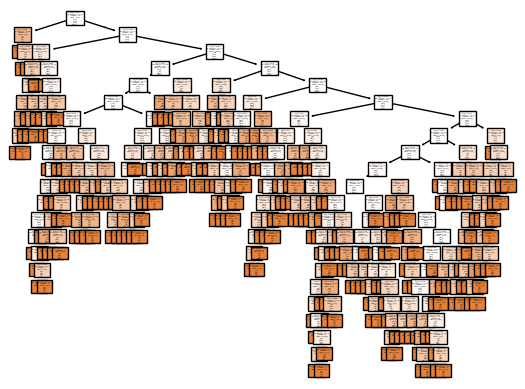

In [29]:
#Plotting Tree in the forest

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plot_tree(rf_model.estimators_[3], filled= True)
plt.show()


In [31]:
#Creating Pickle file

best_model = linreg_model if linreg_mse < rf_mse else rf_model
import pickle

with open('ml_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("Best model saved as 'ml_model.pkl'")


Best model saved as 'ml_model.pkl'
